#  Neural Network — MNIST Digit Classification
## 

**Goal:** Build a feed-forward neural network that classifies handwritten digits (0–9)  
**Dataset:** MNIST — 70,000 handwritten digit images (built into Keras)  
**Model:** Multi-layer Perceptron  with backpropagation  
**Tools:** Python, TensorFlow/Keras, Matplotlib

In [1]:

# IMPORT LIBRARIES

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TensorFlow & Keras — our neural network framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print(f" TensorFlow version: {tf.__version__}")
print(f" Keras version: {keras.__version__}")

 TensorFlow version: 2.20.0
 Keras version: 3.13.2


In [2]:

# IMPORT LIBRARIES


import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TensorFlow & Keras — our neural network framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print(f" TensorFlow version: {tf.__version__}")
print(f" Keras version: {keras.__version__}")

 TensorFlow version: 2.20.0
 Keras version: 3.13.2


 Dataset Overview:
   Training images  : (60000, 28, 28)  ← 60,000 images, each 28x28 pixels
   Training labels  : (60000,)  ← 60,000 correct digit labels
   Test images      : (10000, 28, 28)   ← 10,000 images for evaluation
   Test labels      : (10000,)   ← 10,000 correct digit labels

   Pixel value range: 0 to 255
   Unique digits    : [0 1 2 3 4 5 6 7 8 9]


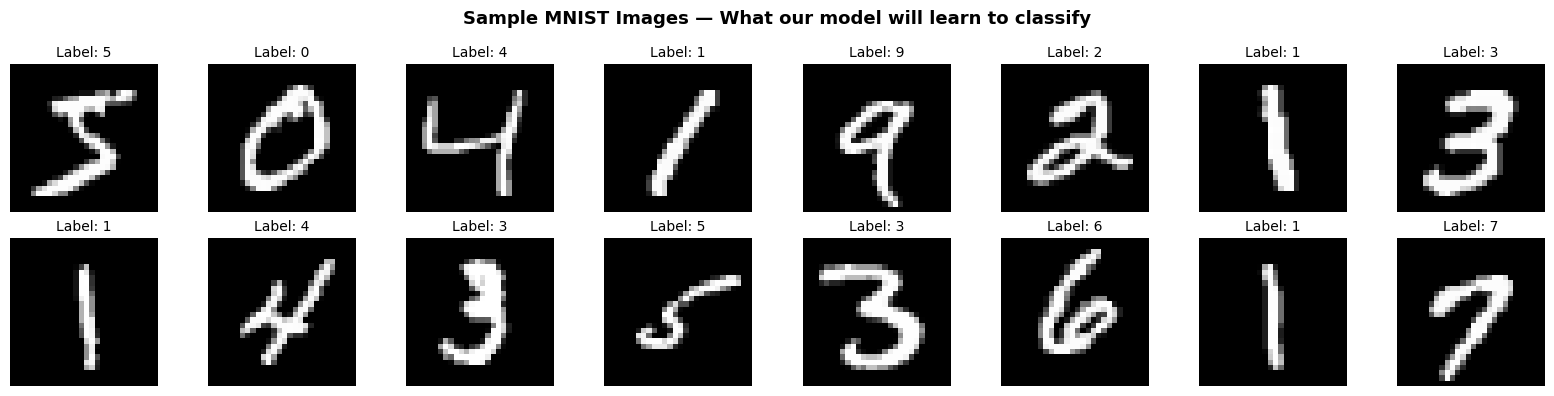

 Sample digits saved!


In [4]:

# LOAD & EXPLORE THE MNIST DATASET


# 70,000 grayscale images of handwritten digits (0-9)
# Each image is 28x28 pixels = 784 numbers

# Load data — Keras downloads it automatically 
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(" Dataset Overview:")
print(f"   Training images  : {X_train.shape}  ← 60,000 images, each 28x28 pixels")
print(f"   Training labels  : {y_train.shape}  ← 60,000 correct digit labels")
print(f"   Test images      : {X_test.shape}   ← 10,000 images for evaluation")
print(f"   Test labels      : {y_test.shape}   ← 10,000 correct digit labels")
print(f"\n   Pixel value range: {X_train.min()} to {X_train.max()}")
print(f"   Unique digits    : {np.unique(y_train)}")

# Visualize the first 16 images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Sample MNIST Images — What our model will learn to classify',
             fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/0_sample_digits.png', dpi=130, bbox_inches='tight')
plt.show()
print(" Sample digits saved!")

In [5]:

#  PREPROCESS DATA

# Neural networks need numbers between 0 and 1
# Raw pixel values are 0–255, so we divide by 255

# Step 1: Normalize pixel values from 0-255 → 0-1
# WHY? Smaller numbers train faster and more stably
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

# Step 2: Flatten images from 28x28 → 784 (one long row of numbers)
# WHY? Our dense neural network needs 1D input, not 2D images
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat  = X_test_norm.reshape(-1, 784)

# Step 3: One-hot encode labels
# WHY? Instead of label "7", network needs [0,0,0,0,0,0,0,1,0,0]
# This lets the output layer have one neuron per digit class
y_train_enc = keras.utils.to_categorical(y_train, 10)
y_test_enc  = keras.utils.to_categorical(y_test,  10)

print(" Preprocessing complete!")
print(f"   Input shape  : {X_train_flat.shape}  ← 60,000 rows of 784 pixels")
print(f"   Output shape : {y_train_enc.shape}  ← 60,000 rows of 10 classes")
print(f"\n   Example label before encoding: {y_train[0]}")
print(f"   Example label after encoding : {y_train_enc[0]}")

 Preprocessing complete!
   Input shape  : (60000, 784)  ← 60,000 rows of 784 pixels
   Output shape : (60000, 10)  ← 60,000 rows of 10 classes

   Example label before encoding: 5
   Example label after encoding : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [6]:

#  BUILD THE NEURAL NETWORK ARCHITECTURE


# Our architecture:

#  INPUT LAYER    784 neurons  (one per pixel)
 #      ↓
#  HIDDEN LAYER 1  128 neurons  (learns basic patterns: edges, curves)
#       ↓
#  HIDDEN LAYER 2   64 neurons  (learns complex patterns: shapes, parts)
#       ↓
#  OUTPUT LAYER     10 neurons  (one per digit)
#
# Each neuron: multiplies inputs by weights, adds bias, applies activation
# Activation ReLU: if negative → 0, if positive → keep it (adds non-linearity)
# Activation Softmax: converts output to probabilities that sum to 1

model = keras.Sequential([
    # Input layer — 784 inputs (one per pixel)
    layers.Input(shape=(784,)),

    # Hidden layer 1 — 128 neurons, ReLU activation
    layers.Dense(128, activation='relu'),
    # Dropout: randomly turn off 20% of neurons during training
    # WHY? Prevents overfitting — forces network to not rely on any one neuron
    layers.Dropout(0.2),

    # Hidden layer 2 — 64 neurons, ReLU activation
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    # Output layer — 10 neurons (one per digit), Softmax activation
    # Softmax converts raw scores → probabilities (all sum to 1.0)
    layers.Dense(10, activation='softmax')
])

# Compile the model — set optimizer, loss function, and metric
model.compile(
    optimizer='adam',       # Adam = smart gradient descent (adjusts learning rate)
    loss='categorical_crossentropy',  # Standard loss for multi-class classification
    metrics=['accuracy']    # We want to track accuracy during training
)

# Print a summary of the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

#  TRAIN THE MODEL (BACKPROPAGATION)
# 
# Training = showing the model examples, checking its mistakes,
# and adjusting weights to reduce errors 
#
# EPOCH = one full pass through all 60,000 training images
# BATCH SIZE = how many images to process before updating weights
# VALIDATION SPLIT = 10% of training data used to monitor overfitting

print(" Training started...")
print("   Each epoch = one full pass through 60,000 images")
print()

history = model.fit(
    X_train_flat, y_train_enc,
    epochs=15,              # Train for 15 full passes
    batch_size=128,         # Process 128 images at a time
    validation_split=0.1,   # Use 10% of train data to validate
    verbose=1               # Show progress for each epoch
)

print("\n Training complete!")

 Training started...
   Each epoch = one full pass through 60,000 images

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8651 - loss: 0.4525 - val_accuracy: 0.9593 - val_loss: 0.1427
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9385 - loss: 0.2115 - val_accuracy: 0.9697 - val_loss: 0.1009
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9523 - loss: 0.1588 - val_accuracy: 0.9732 - val_loss: 0.0907
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9605 - loss: 0.1319 - val_accuracy: 0.9762 - val_loss: 0.0793
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9655 - loss: 0.1138 - val_accuracy: 0.9775 - val_loss: 0.0749
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9695 - loss: 0.1004 - val_accuracy: 0.9813 - val_loss: 0.0690
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9727 - loss: 0.0899 - val_accuracy: 0.9785 - val_loss: 0.0725
Epoch 8/15
422/422 ━━━━━━━━━━━

In [8]:

#  EVALUATE MODEL PERFORMANCE


test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_enc, verbose=0)

print(" Final Model Performance:")
print(f"   Test Accuracy : {test_accuracy*100:.2f}%")
print(f"   Test Loss     : {test_loss:.4f}")
print()

# Get final training and validation accuracy
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
print(f"   Final Training Accuracy   : {final_train_acc*100:.2f}%")
print(f"   Final Validation Accuracy : {final_val_acc*100:.2f}%")
print()
print(f"    Our model correctly classifies {test_accuracy*100:.1f}% of unseen digits!")

 Final Model Performance:
   Test Accuracy : 97.91%
   Test Loss     : 0.0777

   Final Training Accuracy   : 98.39%
   Final Validation Accuracy : 98.43%

    Our model correctly classifies 97.9% of unseen digits!


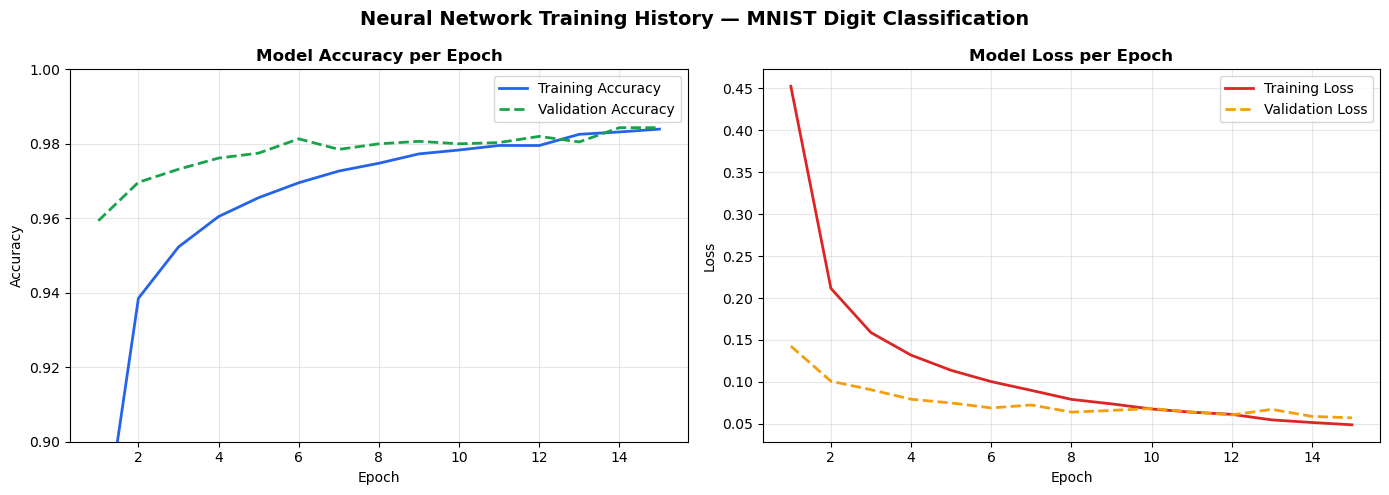

 Training history chart saved!


In [10]:

# VISUALIZE TRAINING HISTORY

# These charts show how the model improved over each epoch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network Training History — MNIST Digit Classification',
             fontsize=14, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

# Chart 1: Accuracy over epochs
ax1 = axes[0]
ax1.plot(epochs_range, history.history['accuracy'],
         color='#2563EB', lw=2, label='Training Accuracy')
ax1.plot(epochs_range, history.history['val_accuracy'],
         color='#16A34A', lw=2, linestyle='--', label='Validation Accuracy')
ax1.set_title('Model Accuracy per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.9, 1.0)

# Chart 2: Loss over epochs
ax2 = axes[1]
ax2.plot(epochs_range, history.history['loss'],
         color='#DC2626', lw=2, label='Training Loss')
ax2.plot(epochs_range, history.history['val_loss'],
         color='#F59E0B', lw=2, linestyle='--', label='Validation Loss')
ax2.set_title('Model Loss per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/1_training_history.png', dpi=130,
            bbox_inches='tight', facecolor='white')
plt.show()
print(" Training history chart saved!")

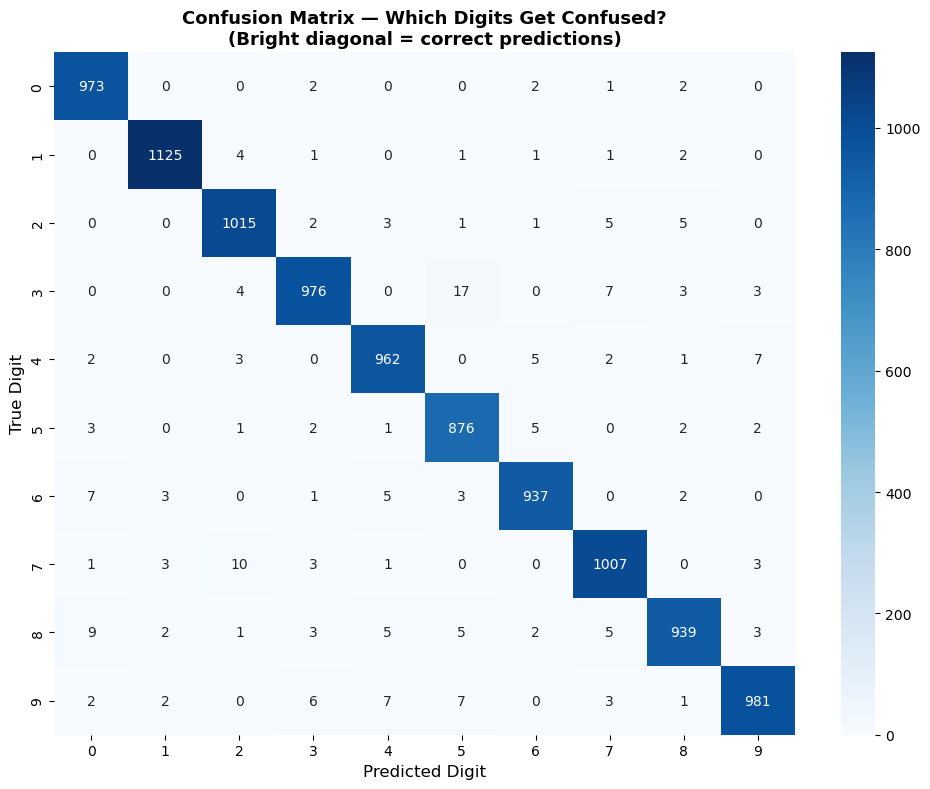

 Confusion matrix saved!


In [12]:
# CONFUSION MATRIX

# Shows which digits the model confuses with each other
# Perfect model = bright diagonal, dark everywhere else

from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred  = np.argmax(model.predict(X_test_flat, verbose=0), axis=1)
cm      = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — Which Digits Get Confused?\n(Bright diagonal = correct predictions)',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Digit', fontsize=12)
plt.ylabel('True Digit',      fontsize=12)
plt.tight_layout()
plt.savefig('outputs/3_confusion_matrix.png', dpi=130,
            bbox_inches='tight', facecolor='white')
plt.show()
print(" Confusion matrix saved!")

In [13]:

# FINAL SUMMARY


print("=" * 55)
print("   MNIST NEURAL NETWORK — FINAL SUMMARY")
print("=" * 55)
print(f"""
  Architecture : 784 → 128 → 64 → 10 neurons
  Parameters   : {model.count_params():,} trainable weights
  Epochs       : 15
  Batch Size   : 128

  RESULTS:
   Test Accuracy  : {test_accuracy*100:.2f}%
   Test Loss      : {test_loss:.4f}

  WHAT THIS MEANS:
  Out of 10,000 unseen handwritten digits,
  our model correctly identifies {int(test_accuracy*10000):,}+ of them.

  OUTPUTS SAVED:
   outputs/0_sample_digits.png
   outputs/1_training_history.png
   outputs/2_predictions.png
   outputs/3_confusion_matrix.png
""")
print("=" * 55)

   MNIST NEURAL NETWORK — FINAL SUMMARY

  Architecture : 784 → 128 → 64 → 10 neurons
  Parameters   : 109,386 trainable weights
  Epochs       : 15
  Batch Size   : 128

  RESULTS:
   Test Accuracy  : 97.91%
   Test Loss      : 0.0777

  WHAT THIS MEANS:
  Out of 10,000 unseen handwritten digits,
  our model correctly identifies 9,790+ of them.

  OUTPUTS SAVED:
   outputs/0_sample_digits.png
   outputs/1_training_history.png
   outputs/2_predictions.png
   outputs/3_confusion_matrix.png

